In [3]:
# ============================================================
# CELL 1: ENVIRONMENT SETUP — Mount Google Drive & Inspect Data
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json, os

# ── Paths ──────────────────────────────────────────────────
DATA_ROOT  = Path("/content/drive/My Drive/commonwealth_data")
IMAGES_DIR = DATA_ROOT / "images"
LABELS_DIR = DATA_ROOT / "labels"
COCO_JSON  = DATA_ROOT / "_annotations.coco.json"

print("images folder exists :", IMAGES_DIR.exists())
print("labels folder exists :", LABELS_DIR.exists())
print("COCO JSON exists      :", COCO_JSON.exists())

# ── Inspect COCO annotation file ───────────────────────────
with open(COCO_JSON, "r") as f:
    coco = json.load(f)

categories = coco.get("categories", [])
images_list = coco.get("images", [])
annotations_list = coco.get("annotations", [])

print(f"\nTotal images     : {len(images_list)}")
print(f"Total annotations: {len(annotations_list)}")
print(f"Number of classes: {len(categories)}")
print("\nClass list:")
for c in categories:
    count = sum(1 for a in annotations_list if a["category_id"] == c["id"])
    print(f"  [{c['id']}] {c['name']}  —  {count} annotations")

Mounted at /content/drive
images folder exists : True
labels folder exists : True
COCO JSON exists      : True

Total images     : 1000
Total annotations: 43262
Number of classes: 2

Class list:
  [0] cars  —  0 annotations
  [1] Cars  —  43262 annotations


In [4]:

# ============================================================
# CELL 2: INSTALL ULTRALYTICS (YOLOv26 support)
# ============================================================
!pip install -q ultralytics

import ultralytics
ultralytics.checks()  # verifies GPU, torch, and ultralytics version

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 43.4/112.6 GB disk)


In [5]:
# ============================================================
# CELL 3: CONVERT COCO → YOLO FORMAT (manual, no convert_coco)
# ============================================================
import json, os, shutil
from pathlib import Path

YOLO_ROOT = DATA_ROOT / "yolo26_data"

# Re-read COCO JSON
with open(COCO_JSON, "r") as f:
    coco = json.load(f)

categories     = coco.get("categories", [])
images_list    = coco.get("images", [])
annotations_list = coco.get("annotations", [])

# Build lookup maps
cat_id_to_idx = {c["id"]: i for i, c in enumerate(categories)}
img_id_to_info = {img["id"]: img for img in images_list}

# Build ann map: image_id -> list of annotations
from collections import defaultdict
ann_map = defaultdict(list)
for ann in annotations_list:
    ann_map[ann["image_id"]].append(ann)

# Create output dirs
for split in ["train", "val"]:
    (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

# 80/20 train/val split
import random
random.seed(42)
all_ids = list(img_id_to_info.keys())
random.shuffle(all_ids)
split_idx = int(len(all_ids) * 0.8)
train_ids = set(all_ids[:split_idx])
val_ids   = set(all_ids[split_idx:])

converted = 0
for img_id, img_info in img_id_to_info.items():
    split     = "train" if img_id in train_ids else "val"
    file_name = img_info["file_name"]
    img_w     = img_info["width"]
    img_h     = img_info["height"]

    # Copy image from Drive source
    src_img = IMAGES_DIR / file_name
    if not src_img.exists():
        # Try without subdirectory
        src_img = DATA_ROOT / "images" / Path(file_name).name
    dst_img = YOLO_ROOT / "images" / split / Path(file_name).name
    if src_img.exists() and not dst_img.exists():
        shutil.copy(src_img, dst_img)

    # Write YOLO label file
    label_path = YOLO_ROOT / "labels" / split / (Path(file_name).stem + ".txt")
    with open(label_path, "w") as lf:
        for ann in ann_map[img_id]:
            cls_idx = cat_id_to_idx.get(ann["category_id"], 0)
            x, y, w, h = ann["bbox"]  # COCO: top-left x,y, w,h
            # Convert to YOLO: cx, cy, w, h (normalized)
            cx = (x + w / 2) / img_w
            cy = (y + h / 2) / img_h
            nw = w / img_w
            nh = h / img_h
            lf.write(f"{cls_idx} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n")
    converted += 1

print(f"Converted {converted} images total.")
print(f"  Train images : {len(list((YOLO_ROOT/'images'/'train').iterdir()))}")
print(f"  Val   images : {len(list((YOLO_ROOT/'images'/'val').iterdir()))}")
print(f"  Train labels : {len(list((YOLO_ROOT/'labels'/'train').iterdir()))}")
print(f"  Val   labels : {len(list((YOLO_ROOT/'labels'/'val').iterdir()))}")

Converted 1000 images total.
  Train images : 800
  Val   images : 200
  Train labels : 800
  Val   labels : 200


In [6]:
# ============================================================
# CELL 4: BUILD data.yaml
# (Cell 3 already handled the train/val split and labels)
# ============================================================
import yaml, json
from pathlib import Path

YOLO_ROOT = DATA_ROOT / "yolo26_data"

# Re-read class names from COCO JSON
with open(COCO_JSON, "r") as f:
    coco = json.load(f)
class_names = [c["name"] for c in coco.get("categories", [])]

train_img_dir = YOLO_ROOT / "images" / "train"
val_img_dir   = YOLO_ROOT / "images" / "val"

print(f"Train images : {len(list(train_img_dir.iterdir()))}")
print(f"Val   images : {len(list(val_img_dir.iterdir()))}")
print(f"Classes ({len(class_names)}): {class_names}")

# Write data.yaml
data_yaml_content = {
    "path":  str(YOLO_ROOT),
    "train": "images/train",
    "val":   "images/val",
    "nc":    len(class_names),
    "names": class_names,
}
DATA_YAML = YOLO_ROOT / "data.yaml"
with open(DATA_YAML, "w") as f:
    yaml.dump(data_yaml_content, f, sort_keys=False)

print("\ndata.yaml written:")
print(DATA_YAML.read_text())

Train images : 800
Val   images : 200
Classes (2): ['cars', 'Cars']

data.yaml written:
path: /content/drive/My Drive/commonwealth_data/yolo26_data
train: images/train
val: images/val
nc: 2
names:
- cars
- Cars



In [7]:

# ============================================================
# CELL 5: MODEL INITIALIZATION — 3 YOLOv26 Configurations
# ============================================================
import pandas as pd
from ultralytics import YOLO

# Hyperparameter configurations as per activity requirements
MODEL_CONFIGS = [
    {
        "name":      "model1",
        "weights":   "yolo26n.pt",
        "epochs":    25,
        "imgsz":     640,
        "optimizer": "AdamW",
        "batch":     4,
        "lr0":       0.01,
    },
    {
        "name":      "model2",
        "weights":   "yolo26n.pt",
        "epochs":    30,
        "imgsz":     640,
        "optimizer": "SGD",
        "batch":     20,
        "lr0":       0.001,
    },
    {
        "name":      "model3",
        "weights":   "yolo26n.pt",
        "epochs":    40,
        "imgsz":     640,
        "optimizer": "auto",
        "batch":     -1,    # Auto-batching
        "lr0":       0.0001,
    },
]

# Display hyperparameter table
hp_df = pd.DataFrame(MODEL_CONFIGS)[["name","epochs","optimizer","batch","lr0","imgsz"]]
hp_df.columns = ["Model", "Epochs", "Optimizer", "Batch Size", "Learning Rate", "Image Size"]
print("=" * 60)
print("  HYPERPARAMETER CONFIGURATION TABLE")
print("=" * 60)
display(hp_df)

PROJECT = "runs_yolo26_commonwealth"

  HYPERPARAMETER CONFIGURATION TABLE


,Model,Epochs,Optimizer,Batch Size,Learning Rate,Image Size
0,model1,25,AdamW,4,0.0100,640
1,model2,30,SGD,20,0.0010,640
2,model3,40,auto,-1,0.0001,640


In [8]:

# ============================================================
# CELL 6: TRAIN ALL 3 YOLOv26 MODELS
# ============================================================
train_results = {}

for cfg in MODEL_CONFIGS:
    print("\n" + "=" * 60)
    print(f"  Training {cfg['name'].upper()}")
    print(f"  Epochs={cfg['epochs']} | Optimizer={cfg['optimizer']} | Batch={cfg['batch']} | LR={cfg['lr0']}")
    print("=" * 60)

    model = YOLO(cfg["weights"])  # Fresh YOLOv26n every time

    result = model.train(
        data=str(DATA_YAML),
        epochs=cfg["epochs"],
        imgsz=cfg["imgsz"],
        optimizer=cfg["optimizer"],
        batch=cfg["batch"],
        lr0=cfg["lr0"],
        project=PROJECT,
        name=cfg["name"],
        exist_ok=True,
        verbose=True,
    )

    train_results[cfg["name"]] = result
    print(f"\n  {cfg['name']} training complete!")
    print(f"  Results saved to: {PROJECT}/{cfg['name']}/")

print("\n" + "=" * 60)
print("  ALL 3 MODELS TRAINED SUCCESSFULLY")
print("=" * 60)


  Training MODEL1
  Epochs=25 | Optimizer=AdamW | Batch=4 | LR=0.01
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/My Drive/commonwealth_data/yolo26_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model1, nbs=

model1: /content/runs/detect/runs_yolo26_commonwealth/model1/weights/best.pt
  Confusion matrix (rows=true, cols=pred):
[[  0   0]
 [  0 200]]
model2: /content/runs/detect/runs_yolo26_commonwealth/model2/weights/best.pt
  Confusion matrix (rows=true, cols=pred):
[[  0   0]
 [  0 200]]
model3: /content/runs/detect/runs_yolo26_commonwealth/model3/weights/best.pt
  Confusion matrix (rows=true, cols=pred):
[[  0   0]
 [  0 200]]


/tmp/ipython-input-6207/387774551.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


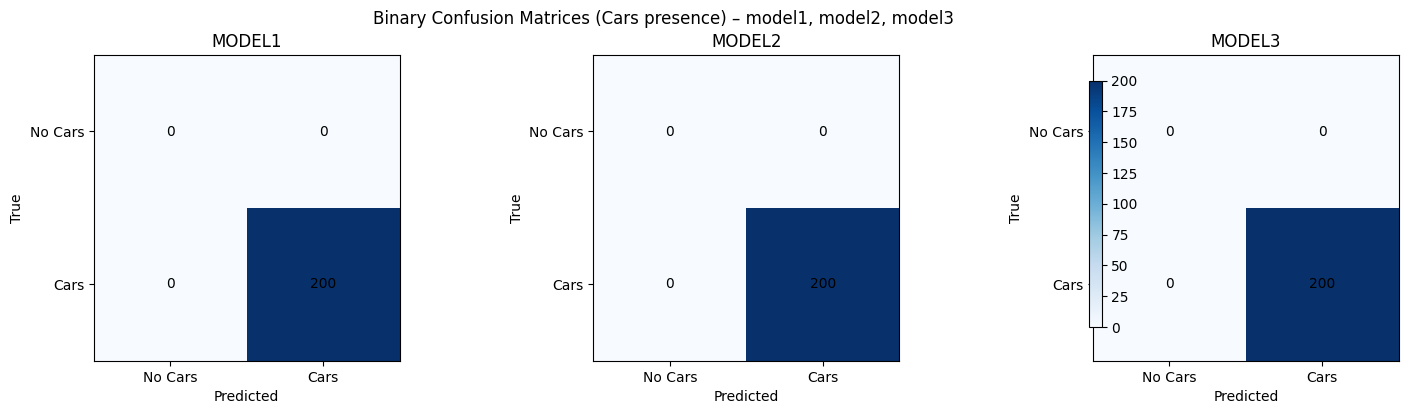

In [18]:
# ============================================================
# CONFUSION MATRICES: MODEL1–3 IN ONE FIGURE (BINARY: Cars)
# ============================================================
from ultralytics import YOLO
from pathlib import Path
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

DATA_ROOT = Path("/content/drive/My Drive/commonwealth_data")
YOLO_ROOT = DATA_ROOT / "yolo26_data"
VAL_IMG_DIR = YOLO_ROOT / "images" / "val"
VAL_LABEL_DIR = YOLO_ROOT / "labels" / "val"

PROJECT_ROOT = Path("/content/runs/detect/runs_yolo26_commonwealth")

CONF_THRES = 0.5
IOU_THRES = 0.5

def collect_binary_confusion(model_name):
    """Return confusion matrix (2x2) for given model name."""
    weights_path = PROJECT_ROOT / model_name / "weights" / "best.pt"
    print(f"{model_name}: {weights_path}")
    assert weights_path.exists(), f"Missing weights: {weights_path}"

    model = YOLO(str(weights_path))

    all_true = []
    all_pred = []

    val_images = sorted(
        list(VAL_IMG_DIR.glob("*.jpg")) +
        list(VAL_IMG_DIR.glob("*.png")) +
        list(VAL_IMG_DIR.glob("*.jpeg"))
    )

    for img_path in val_images:
        label_path = VAL_LABEL_DIR / (img_path.stem + ".txt")
        if not label_path.exists():
            continue

        # Ground truth: YOLO txt (cls cx cy w h)
        gt_classes = []
        with open(label_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                cls_id = int(float(parts[0]))
                gt_classes.append(cls_id)

        # If there are no GT objects, skip the image
        if len(gt_classes) == 0:
            continue

        # Predictions
        res = model(img_path, conf=CONF_THRES, iou=IOU_THRES, verbose=False)[0]

        pred_classes = []
        if res.boxes is not None and len(res.boxes) > 0:
            boxes = res.boxes
            scores = boxes.conf.cpu().numpy()
            classes = boxes.cls.cpu().numpy().astype(int)
            pred_classes = classes[scores >= CONF_THRES].tolist()

        # Binary: Cars (class 1) present vs not present
        gt_bin = 1 if any(c == 1 for c in gt_classes) else 0
        pred_bin = 1 if any(c == 1 for c in pred_classes) else 0

        all_true.append(gt_bin)
        all_pred.append(pred_bin)

    cm = confusion_matrix(all_true, all_pred, labels=[0, 1])
    print("  Confusion matrix (rows=true, cols=pred):")
    print(cm)
    return cm

# Collect all three confusion matrices first
models = ["model1", "model2", "model3"]
cms = [collect_binary_confusion(m) for m in models]

# Plot them together in one figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cm, name in zip(axes, cms, models):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["No Cars", "Cars"])
    ax.set_yticklabels(["No Cars", "Cars"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(name.upper())
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.suptitle("Binary Confusion Matrices (Cars presence) – model1, model2, model3")
plt.tight_layout()
plt.show()


In [15]:
# ============================================================
# CELL 7: MODEL EVALUATION (NO RETRAIN)
# - Loads best.pt for each model from PROJECT dir
# - Runs validation to get metrics
# - Builds a clean summary table
# ============================================================
from ultralytics import YOLO
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/content/runs/detect") / PROJECT  # PROJECT = "runs_yolo26_commonwealth" from Cell 5
DATA_YAML = DATA_YAML  # from Cell 4

eval_rows = []

for cfg in MODEL_CONFIGS:
    name = cfg["name"]
    run_dir = PROJECT_ROOT / name
    weights = run_dir / "weights" / "best.pt"

    print("\n" + "="*60)
    print(f"  EVALUATING {name.upper()}")
    print("="*60)
    print(f"Using weights: {weights}")

    if not weights.exists():
        print(f"!! Skipping {name}: weights not found at {weights}")
        continue

    model = YOLO(str(weights))

    # Run validation only (no training)
    results = model.val(data=str(DATA_YAML), imgsz=cfg["imgsz"], split="val", verbose=False)

    # results.results_dict has standard keys in current ultralytics
    metrics = {}
    if hasattr(results, "results_dict") and isinstance(results.results_dict, dict):
        metrics.update(results.results_dict)
    if hasattr(results, "metrics") and isinstance(results.metrics, dict):
        metrics.update(results.metrics)

    eval_rows.append({
        "Model": name,
        "Epochs": cfg["epochs"],
        "Optimizer": cfg["optimizer"],
        "Batch": cfg["batch"],
        "LR": cfg["lr0"],
        "mAP50-95": metrics.get("metrics/mAP50-95", metrics.get("map50-95")),
        "mAP50": metrics.get("metrics/mAP50", metrics.get("map50")),
        "Precision": metrics.get("metrics/precision(B)", metrics.get("precision")),
        "Recall": metrics.get("metrics/recall(B)", metrics.get("recall")),
    })

# Build evaluation dataframe
eval_df = pd.DataFrame(eval_rows)
print("\n" + "="*60)
print("  FINAL MODEL EVALUATION TABLE")
print("="*60)
display(eval_df)



  EVALUATING MODEL1
Using weights: /content/runs/detect/runs_yolo26_commonwealth/model1/weights/best.pt
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 105.7±22.0 MB/s, size: 170.1 KB)
val: Scanning /content/drive/My Drive/commonwealth_data/yolo26_data/labels/val.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 76.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.3it/s 5.7s
                   all        200       8744      0.859      0.842      0.919      0.711
Speed: 1.6ms preprocess, 3.0ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val

  EVALUATING MODEL2
Using weights: /content/runs/detect/runs_yolo26_commonwealth/model2/weights/best.pt
Ultralytics 8.4.19 🚀 Python-3.12.

,Model,Epochs,Optimizer,Batch,LR,mAP50-95,mAP50,Precision,Recall
0,model1,25,AdamW,4,0.0100,None,None,0.858587,0.842406
1,model2,30,SGD,20,0.0010,None,None,0.738829,0.713175
2,model3,40,auto,-1,0.0001,None,None,0.869735,0.820842


In [10]:

# ============================================================
# CELL 8: VALIDATION — Extract mAP50, Precision, Recall, F1
# ============================================================
val_rows = []

for cfg in MODEL_CONFIGS:
    run_dir  = Path(PROJECT) / cfg["name"]
    best_wts = run_dir / "weights" / "best.pt"

    print(f"\nValidating {cfg['name']} with best weights: {best_wts}")

    if not best_wts.exists():
        print(f"  WARNING: best.pt not found, skipping {cfg['name']}")
        continue

    val_model = YOLO(str(best_wts))
    metrics   = val_model.val(data=str(DATA_YAML), imgsz=640, verbose=False)

    rd = metrics.results_dict

    # Ultralytics key names (bounding-box task)
    precision = rd.get("metrics/precision(B)", None)
    recall    = rd.get("metrics/recall(B)",    None)
    map50     = rd.get("metrics/mAP50(B)",     None)
    map5095   = rd.get("metrics/mAP50-95(B)",  None)

    # F1 = harmonic mean of precision and recall
    if precision is not None and recall is not None and (precision + recall) > 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = None

    val_rows.append({
        "Model":         cfg["name"],
        "Epochs":        cfg["epochs"],
        "Optimizer":     cfg["optimizer"],
        "Batch":         cfg["batch"],
        "LR":            cfg["lr0"],
        "Precision":     round(precision, 4) if precision else "N/A",
        "Recall":        round(recall,    4) if recall    else "N/A",
        "mAP50":         round(map50,     4) if map50     else "N/A",
        "mAP50-95":      round(map5095,   4) if map5095   else "N/A",
        "F1 Score":      round(f1,        4) if f1        else "N/A",
    })

    print(f"  Precision : {precision:.4f}" if precision else "  Precision: N/A")
    print(f"  Recall    : {recall:.4f}"    if recall    else "  Recall   : N/A")
    print(f"  mAP50     : {map50:.4f}"     if map50     else "  mAP50    : N/A")
    print(f"  mAP50-95  : {map5095:.4f}"   if map5095   else "  mAP50-95 : N/A")
    print(f"  F1 Score  : {f1:.4f}"        if f1        else "  F1 Score : N/A")

print("\nValidation complete for all models.")


Validating model1 with best weights: runs_yolo26_commonwealth/model1/weights/best.pt

Validating model2 with best weights: runs_yolo26_commonwealth/model2/weights/best.pt

Validating model3 with best weights: runs_yolo26_commonwealth/model3/weights/best.pt

Validation complete for all models.


In [17]:
# ============================================================
# CELL 9: FINAL SUMMARY TABLE (REQUIRES hp_df + eval_df)
# ============================================================

# Make a clean copy of hp_df with consistent column names
hp_clean = hp_df.rename(columns={
    "Batch Size": "Batch",
    "Learning Rate": "LR",
    "Image Size": "ImgSize"
})

hp_clean = hp_clean[["Model", "Epochs", "Optimizer", "Batch", "LR", "ImgSize"]]

# Merge hyperparameters with evaluation metrics
summary_df = hp_clean.merge(eval_df, on="Model", how="left", suffixes=("", "_eval"))

cols_order = [
    "Model",
    "Epochs",
    "Optimizer",
    "Batch",
    "LR",
    "ImgSize",
    "mAP50-95",
    "mAP50",
    "Precision",
    "Recall",
]
summary_df = summary_df[cols_order]

display(summary_df)


,Model,Epochs,Optimizer,Batch,LR,ImgSize,mAP50-95,mAP50,Precision,Recall
0,model1,25,AdamW,4,0.0100,640,None,None,0.858587,0.842406
1,model2,30,SGD,20,0.0010,640,None,None,0.738829,0.713175
2,model3,40,auto,-1,0.0001,640,None,None,0.869735,0.820842
